# Algoritmo Genético (DEAP) – X desde CSV y y escalar
Este notebook carga X desde CSV, expande un y escalar, preprocesa (400–2100 nm, ×3, opcional N=300),
usa una fitness adaptable (SVM/OneClassSVM) y corre el GA con DEAP.

In [1]:
#!pip install numpy pandas scikit-learn deap matplotlib --quiet
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from functools import lru_cache
from dataclasses import dataclass
from time import time
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, OneClassSVM
from sklearn.metrics import make_scorer, balanced_accuracy_score
from deap import base, creator, tools

SEED = 42
rng = np.random.default_rng(SEED)
print('SEED =', SEED)

SEED = 42


## Cargar X desde CSV y y escalar

In [2]:
CSV_PATH = '/Users/dylanjitton/Documents/project_plantDisease/Exported/reflectance_valid.csv'
WAVELENGTHS_CSV = ''# '/Users/dylanjitton/Documents/project_plantDisease/Exported/longitudescsv.csv'  # opcional
Y_SCALAR = 1

df = pd.read_csv(CSV_PATH)
print('CSV X:', CSV_PATH, '| shape =', df.shape)
display(df.head(3))

wavelengths = None
try:
    wavelengths = np.array([float(c) for c in df.columns], dtype=float)
    print('wavelengths detectadas desde encabezados (nm).')
except Exception:
    try:
        wl_df = pd.read_csv(WAVELENGTHS_CSV)
        for c in ['wavelength_nm','wavelength','nm','lambda','longitud_onda']:
            if c in wl_df.columns:
                wavelengths = wl_df[c].values.astype(float)
                break
        if wavelengths is not None and wavelengths.shape[0] != df.shape[1]:
            raise ValueError('Longitudes no coinciden con columnas de X')
        print('wavelengths cargadas desde archivo externo.')
    except Exception as e:
        print('Sin wavelengths explícitas. Motivo:', e)

X_np = df.select_dtypes(include=[np.number]).values.astype(float)
X_list_of_lists = X_np.tolist()  # array de arrays solicitado
print('X_np shape:', X_np.shape, '| ejemplo fila 0:', X_np[0, :5])

y = np.full(shape=(X_np.shape[0],), fill_value=Y_SCALAR, dtype=int)
print('y -> shape:', y.shape, '| únicos:', np.unique(y))

CSV X: /Users/dylanjitton/Documents/project_plantDisease/Exported/reflectance_valid.csv | shape = (2888, 206)


,y,x,397.32,400.20,403.09,405.97,408.85,411.74,414.63,417.52,...,975.79,978.88,981.96,985.05,988.13,991.22,994.31,997.40,1000.49,1003.58
0,18,53,0.004261,0.003348,0.002717,0.003049,0.002660,0.002907,0.002572,0.002528,...,0.034856,0.034091,0.033910,0.034801,0.034639,0.034091,0.034722,0.034926,0.034722,0.026620
1,18,54,0.032752,0.026657,0.023912,0.022136,0.021521,0.020372,0.018795,0.016605,...,0.232057,0.226736,0.232048,0.229158,0.231671,0.235556,0.237158,0.231618,0.233243,0.185964
2,18,55,0.007102,0.006109,0.006295,0.004218,0.004960,0.003789,0.003865,0.003690,...,0.046629,0.046503,0.046543,0.047161,0.047697,0.047276,0.046007,0.048178,0.046270,0.036721


Sin wavelengths explícitas. Motivo: [Errno 2] No such file or directory: ''
X_np shape: (2888, 206) | ejemplo fila 0: [1.8000000e+01 5.3000000e+01 4.2613638e-03 3.3482143e-03 2.7173914e-03]
y -> shape: (2888,) | únicos: [1]


## Preprocesado (400–2100 nm, ×3, opcional N=300)

In [3]:
LOW, HIGH = 400.0, 2100.0
SUBSAMPLE = 3
USE_GENOME_300 = True

X_proc = X_np.copy()
wl_proc = wavelengths.copy() if wavelengths is not None else None

if wl_proc is not None:
    mask = (wl_proc >= LOW) & (wl_proc <= HIGH)
    X_proc = X_proc[:, mask]
    wl_proc = wl_proc[mask]

X_proc = X_proc[:, ::SUBSAMPLE]
if wl_proc is not None:
    wl_proc = wl_proc[::SUBSAMPLE]

if USE_GENOME_300 and X_proc.shape[1] > 300:
    idx = np.linspace(0, X_proc.shape[1]-1, 300).astype(int)
    X_proc = X_proc[:, idx]
    if wl_proc is not None:
        wl_proc = wl_proc[idx]

print('X_proc shape:', X_proc.shape)
if wl_proc is not None:
    print('wl_proc shape:', wl_proc.shape)

X_proc shape: (2888, 69)


## Fitness adaptable (SVM/OneClassSVM)

In [4]:
def make_fitness_fn_adaptable(X, y, *, n_splits=10, seed=SEED, C=2.0, gamma='scale',
                               class_weight='balanced', lambda_=0.0):
    y_unique = np.unique(y)
    if y_unique.size >= 2:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        scorer = make_scorer(balanced_accuracy_score)
        clf = Pipeline([('scaler', StandardScaler()),
                        ('svc', SVC(kernel='rbf', C=C, gamma=gamma, class_weight=class_weight))])
        @lru_cache(maxsize=None)
        def _eval_cached(cols_tuple):
            cols = np.fromiter(cols_tuple, dtype=int)
            if cols.size == 0:
                return 0.0
            Xsub = X[:, cols]
            scores = cross_val_score(clf, Xsub, y, cv=skf, scoring=scorer, n_jobs=None)
            acc = float(np.mean(scores))
            penalty = lambda_ * (cols.size / X.shape[1])
            return acc - penalty
        def fitness(ind_bits):
            sel = np.flatnonzero(np.array(ind_bits, dtype=np.int8))
            return _eval_cached(tuple(sel))
        return fitness
    else:
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        oc_clf = Pipeline([('scaler', StandardScaler()),
                           ('ocsvm', OneClassSVM(kernel='rbf', gamma='scale', nu=0.05))])
        @lru_cache(maxsize=None)
        def _eval_cached(cols_tuple):
            cols = np.fromiter(cols_tuple, dtype=int)
            if cols.size == 0:
                return 0.0
            Xsub = X[:, cols]
            scores = []
            for tr, te in kf.split(Xsub):
                oc_clf.fit(Xsub[tr])
                pred = oc_clf.predict(Xsub[te])  # +1 inlier, -1 outlier
                scores.append((pred == 1).mean())
            acc = float(np.mean(scores))
            penalty = lambda_ * (cols.size / X.shape[1])
            return acc - penalty
        def fitness(ind_bits):
            sel = np.flatnonzero(np.array(ind_bits, dtype=np.int8))
            return _eval_cached(tuple(sel))
        return fitness

## GA (DEAP) y ejecución

Mejor fitness: 0.9518683322039184
#Bandas seleccionadas: 31 / 69


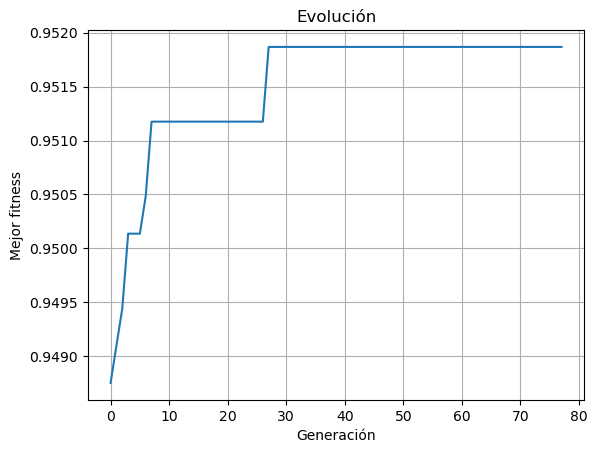

In [5]:
def setup_deap(N_features: int):
    if not hasattr(creator, 'FitnessMax'):
        creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    if not hasattr(creator, 'Individual'):
        creator.create('Individual', np.ndarray, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register('attr_bool', rng.integers, 0, 2)
    toolbox.register('individual', tools.initRepeat, creator.Individual, toolbox.attr_bool, n=N_features)
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    return toolbox

@dataclass
class GAConfig:
    pop_size: int = 300
    gens: int = 300
    pc: float = 0.8
    indpb: float = 0.02
    tournsize: int = 2
    elite_k: int = 2
    stall_limit: int = 50

def run_ga_deap(X, y, fitness_fn, ga_cfg: GAConfig):
    N = X.shape[1]
    toolbox = setup_deap(N)
    def evaluate(ind):
        return (fitness_fn(np.array(ind, dtype=np.int8)),)
    toolbox.register('evaluate', evaluate)
    toolbox.register('mate', tools.cxTwoPoint)
    toolbox.register('mutate', tools.mutFlipBit, indpb=ga_cfg.indpb)
    toolbox.register('select', tools.selTournament, tournsize=ga_cfg.tournsize)
    pop = toolbox.population(n=ga_cfg.pop_size)
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)
    best = tools.selBest(pop, 1)[0]
    best_fit = best.fitness.values[0]
    history = [best_fit]
    stall = 0
    t0 = time()
    for g in range(1, ga_cfg.gens + 1):
        elites = tools.selBest(pop, ga_cfg.elite_k)
        offspring = toolbox.select(pop, len(pop) - ga_cfg.elite_k)
        offspring = list(map(toolbox.clone, offspring))
        for i in range(0, len(offspring), 2):
            if i + 1 < len(offspring) and rng.random() < ga_cfg.pc:
                toolbox.mate(offspring[i], offspring[i + 1])
                del offspring[i].fitness.values, offspring[i + 1].fitness.values
        for ind in offspring:
            toolbox.mutate(ind)
            del ind.fitness.values
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid:
            ind.fitness.values = toolbox.evaluate(ind)
        pop = elites + offspring
        current_best = tools.selBest(pop, 1)[0]
        current_fit = current_best.fitness.values[0]
        if current_fit > best_fit:
            best, best_fit = current_best, current_fit
            stall = 0
        else:
            stall += 1
        history.append(best_fit)
        if stall >= ga_cfg.stall_limit:
            break
    t1 = time()
    best_bits = np.array(best, dtype=np.int8)
    selected_idx = np.flatnonzero(best_bits)
    print('Mejor fitness:', best_fit)
    print('#Bandas seleccionadas:', selected_idx.size, '/', X.shape[1])
    if 'wl_proc' in globals() and wl_proc is not None and selected_idx.size>0:
        print('Primeras longitudes seleccionadas:', np.round(wl_proc[selected_idx][:10],2))
    return {'best_bits': best_bits, 'selected_idx': selected_idx,
            'best_fitness': best_fit, 'history': np.array(history),
            'runtime_sec': t1 - t0}

fitness_fn = make_fitness_fn_adaptable(X_proc, y, n_splits=10, seed=SEED,
                                       C=2.0, gamma='scale', class_weight='balanced', lambda_=0.0)
ga_cfg = GAConfig()
results = run_ga_deap(X_proc, y, fitness_fn, ga_cfg)

plt.figure(); plt.plot(results['history']); plt.grid(True)
plt.xlabel('Generación'); plt.ylabel('Mejor fitness'); plt.title('Evolución'); plt.show()

## Exportar selección a CSV

In [6]:
out = {'index': results['selected_idx']}
if 'wl_proc' in globals() and wl_proc is not None and results['selected_idx'].size>0:
    out['wavelength_nm'] = wl_proc[results['selected_idx']]
pd.DataFrame(out).to_csv('bandas_seleccionadas_desde_csv_scalarY.csv', index=False)
print('Guardado: bandas_seleccionadas_desde_csv_scalarY.csv')

Guardado: bandas_seleccionadas_desde_csv_scalarY.csv
